## Problem Statement :

- Businesses lose customers over time, which directly reduces revenue and increases acquisition costs.
- The goal is to predict which customers are likely to churn so proactive retention strategies can be applied.



## How the Model Solves the Problem :

- The model analyzes historical customer data (usage, behavior, contract details, etc.) and identifies patterns that indicate churn risk.
- It then assigns a probability score to each customer, allowing the business to target high-risk users before they leave.

### Example :

* **Example 1:**
  If 1,000 customers are at risk and the model correctly identifies 700, the company can intervene (offers/support) and retain a significant portion → direct revenue saved.

* **Example 2:**
  Without the model, retention efforts are random → money wasted on low-risk customers while real churners leave unnoticed.

In [125]:
# Import required Libraries
import numpy as np
import pandas as pd

# LOAD AND INSPECT DATASET

In [126]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [127]:
# Display Top 5 Rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [128]:
# Displays column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [129]:
df.shape

(7043, 21)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [131]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


# Observations :         
- TotalCharges is object but should be numeric
- SeniorCitizen is int64 but actually represents categorical (0/1) → misleading type.

In [132]:
# to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [133]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [135]:
# check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [136]:
df = df.dropna(subset=['TotalCharges'])

In [137]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


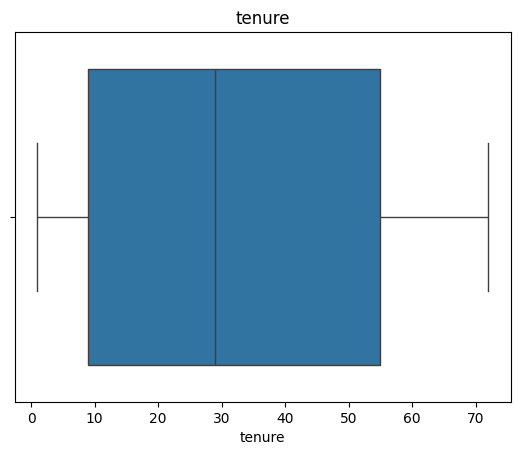

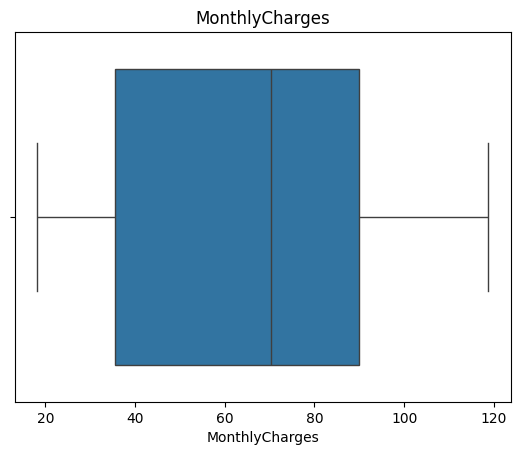

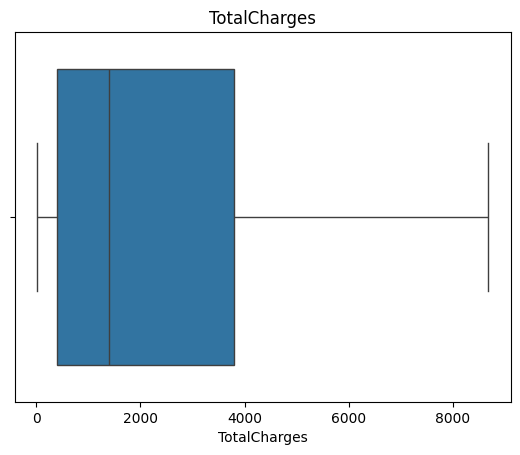

In [138]:
# Outlier detection
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Observation :         
- No outliers
- Even if outliers are there,we don't remove because
    - High MonthlyCharges → not an outlier → premium customers

    - High TotalCharges → long tenure customers → valuable, not noise

In [139]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [140]:
df.drop('customerID', axis=1, inplace=True)

# EDA

### Is dataset balanced ?
- It helps in choosing model evaluation metric

In [141]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


### Checking which category increase churn probability

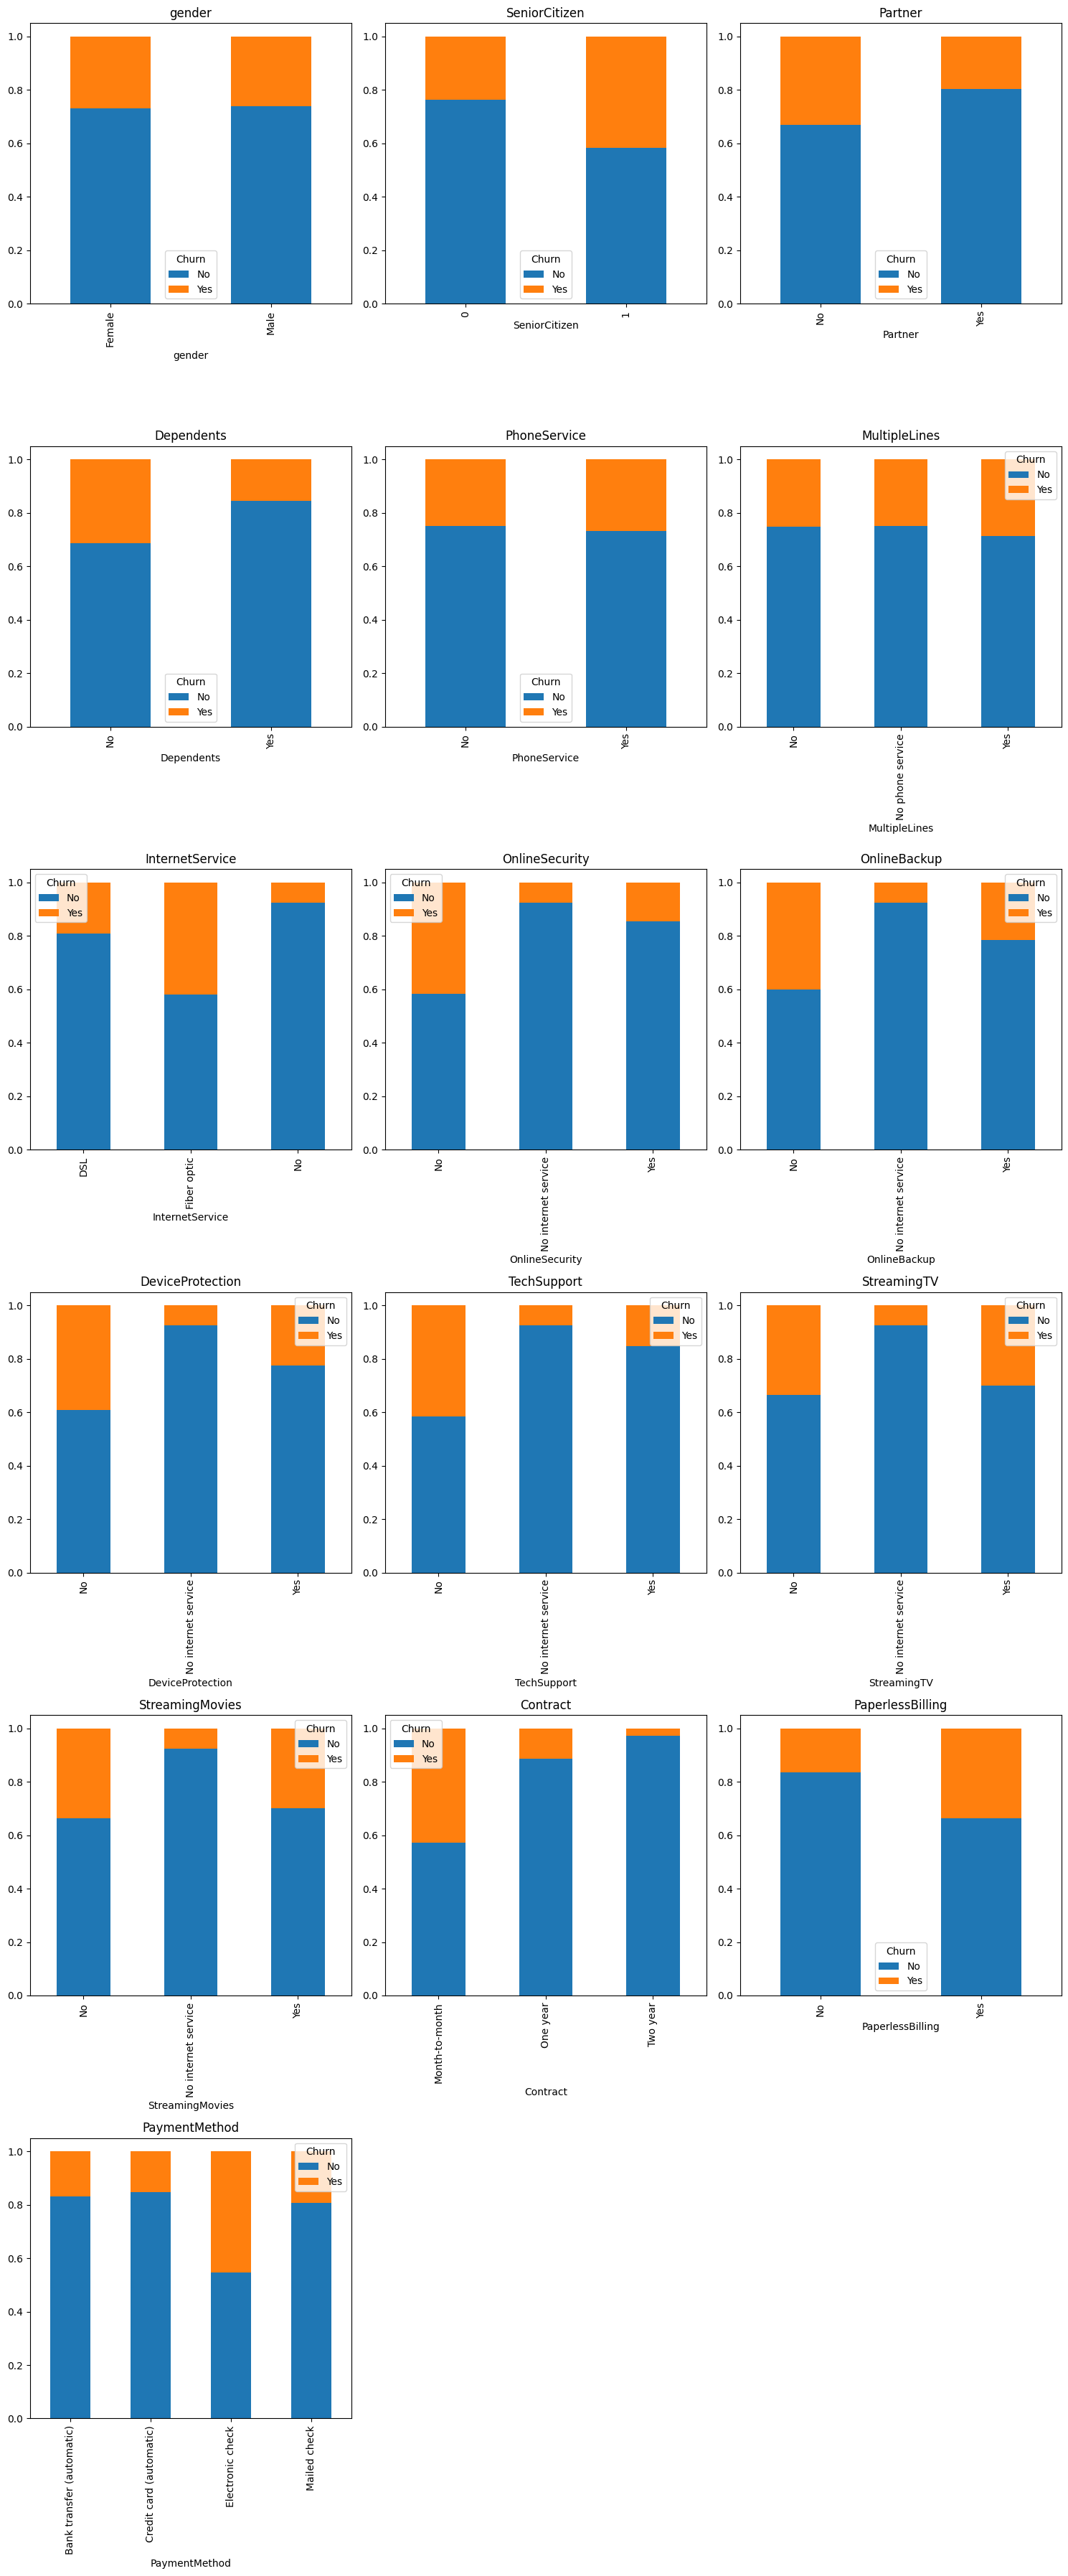

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

cat_cols = df.select_dtypes(include='object').columns
cat_cols = [col for col in cat_cols if col != 'Churn']

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    churn_rate.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(col)

# remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Key Observations :       

* **Contract type is the strongest signal** — month-to-month customers churn heavily, long-term contracts retain customers.
* **Lack of support/services (OnlineSecurity, TechSupport)** clearly increases churn → service quality matters.
* **Fiber optic users show higher churn** compared to DSL/no internet → possible pricing or service dissatisfaction.
* **Electronic check users churn more**, while auto-payment users are more stable → payment behavior reflects commitment.
* **Tenure-related pattern (indirectly visible)** — low-engagement users churn early, long-term users stay.
* **Gender, PhoneService, MultipleLines show almost no difference** → weak or negligible impact on churn.

### Numerical vs Churn

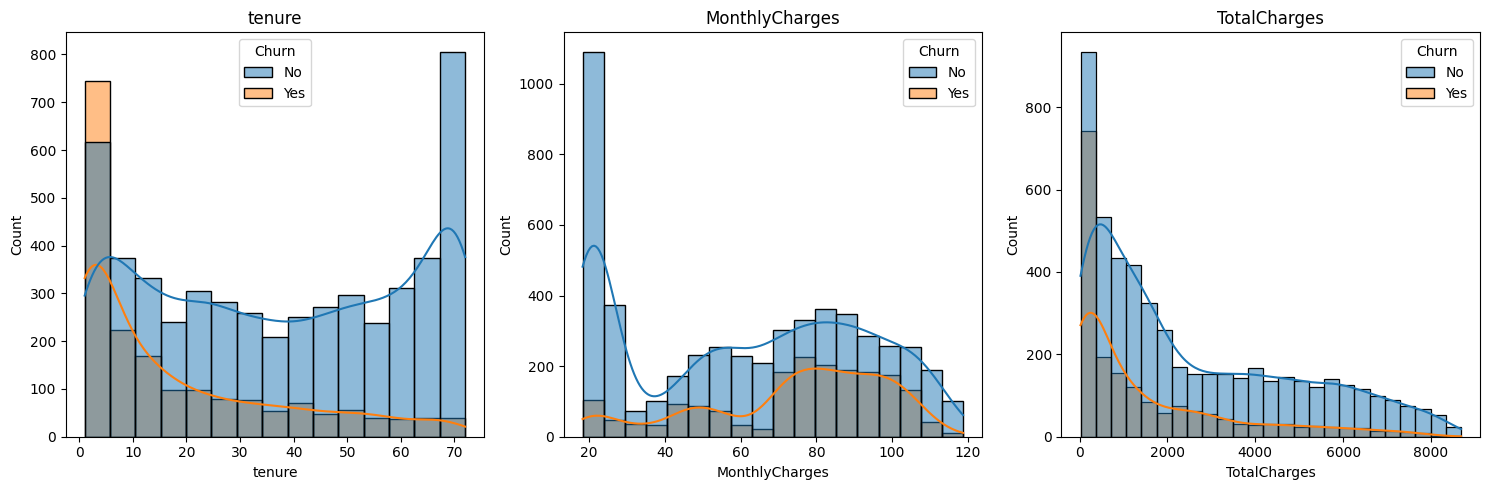

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## Numerical Features — Key Observations

* **Tenure is the strongest signal** — churn is very high for low tenure (0–10 months) and drops sharply as tenure increases.

* **Long-term customers (high tenure) rarely churn**, showing strong customer stability over time.

* **MonthlyCharges shows a clear pattern** — higher charges are associated with higher churn rates.

* Low-charge customers are more stable → price sensitivity is a real factor.

* **TotalCharges is heavily skewed** — most churn happens at low total charges.

* High total charges (long-term customers) show very low churn → reflects tenure effect.



## Reality Insight

* `TotalCharges ≈ tenure × MonthlyCharges` → **redundant feature**
* So:

  * Keeping all three blindly = multicollinearity (bad for linear models)

# Feature Importance

In [144]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# quick encoding (temporary for importance only)
df_temp = df.copy()

le = LabelEncoder()
for col in df_temp.select_dtypes(include='object').columns:
    df_temp[col] = le.fit_transform(df_temp[col])

X = df_temp.drop('Churn', axis=1)
y = df_temp['Churn']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances_pct = (importances.sort_values(ascending=False) * 100).round(2)

print("Feature Importances (%):")
print(importances_pct)


Feature Importances (%):
TotalCharges        19.16
MonthlyCharges      18.13
tenure              15.70
Contract             7.88
PaymentMethod        5.06
OnlineSecurity       4.60
TechSupport          4.42
gender               2.75
OnlineBackup         2.74
InternetService      2.59
PaperlessBilling     2.56
Partner              2.35
MultipleLines        2.13
DeviceProtection     2.12
SeniorCitizen        2.07
Dependents           1.95
StreamingMovies      1.68
StreamingTV          1.64
PhoneService         0.49
dtype: float64


## Feature Importance Observations
- Top 3 dominate: TotalCharges, MonthlyCharges, tenure → core drivers are money + time
- Contract + PaymentMethod → strong behavioral signals (commitment)
- Service features (OnlineSecurity, TechSupport) → moderate but meaningful impact
- Most remaining features sit in 2–3% range → weak individual impact, but not zero
- PhoneService is almost useless (0.49%) → clear drop candidate
- Many features are redundant/noisy rather than harmful individually

In [145]:
df = df.drop(columns=['TotalCharges', 'PhoneService'])

## Why we dropped Total Charges though it's 19% Important
- TotalCharges ≈ tenure × MonthlyCharges
- Same TotalCharges → completely different behavior
- same signal counted multiple times
- model becomes biased toward financial features

## Plots

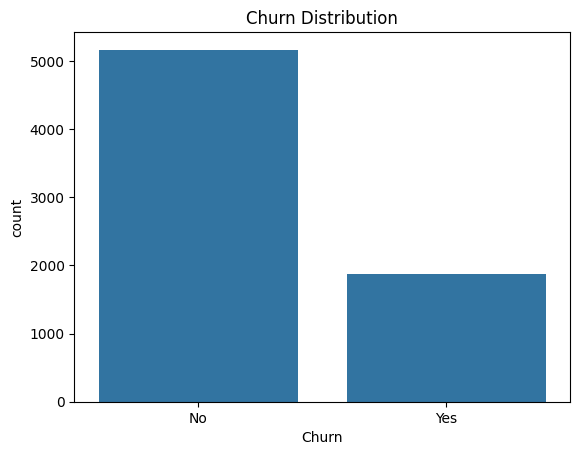

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Observations :     
- Imbalanced dataset
- Need to handle it

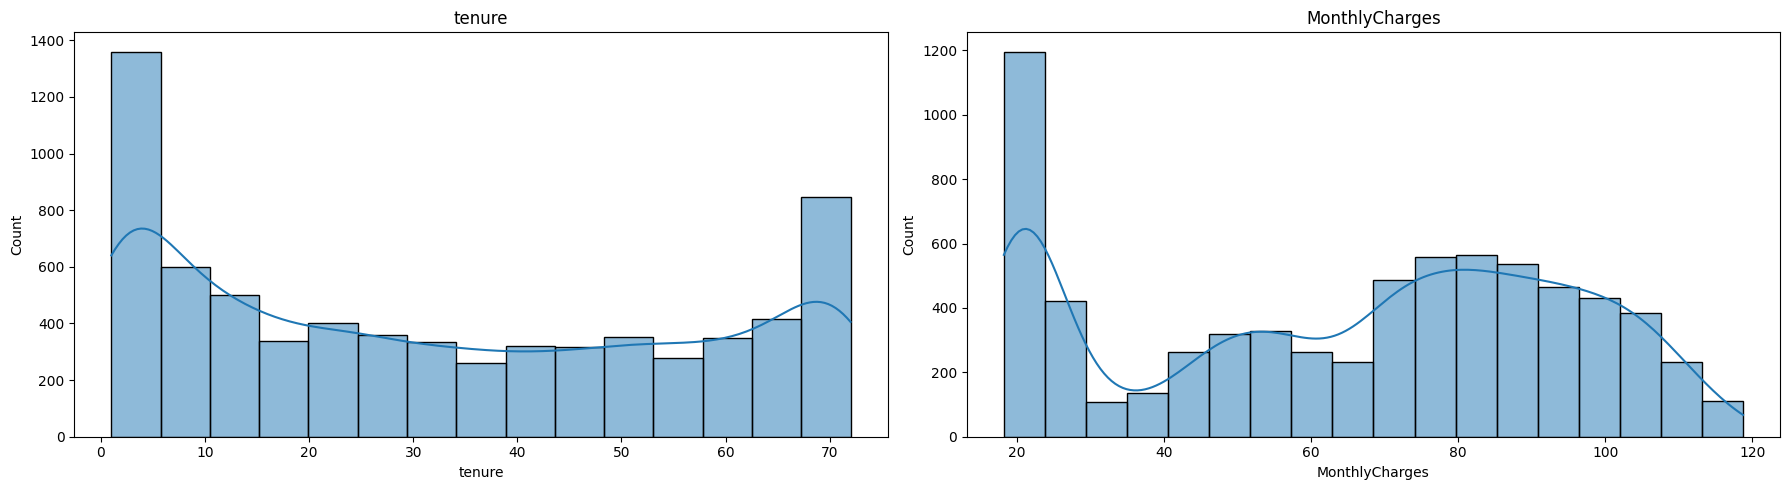

In [147]:
import math

num_cols = ['tenure', 'MonthlyCharges']

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

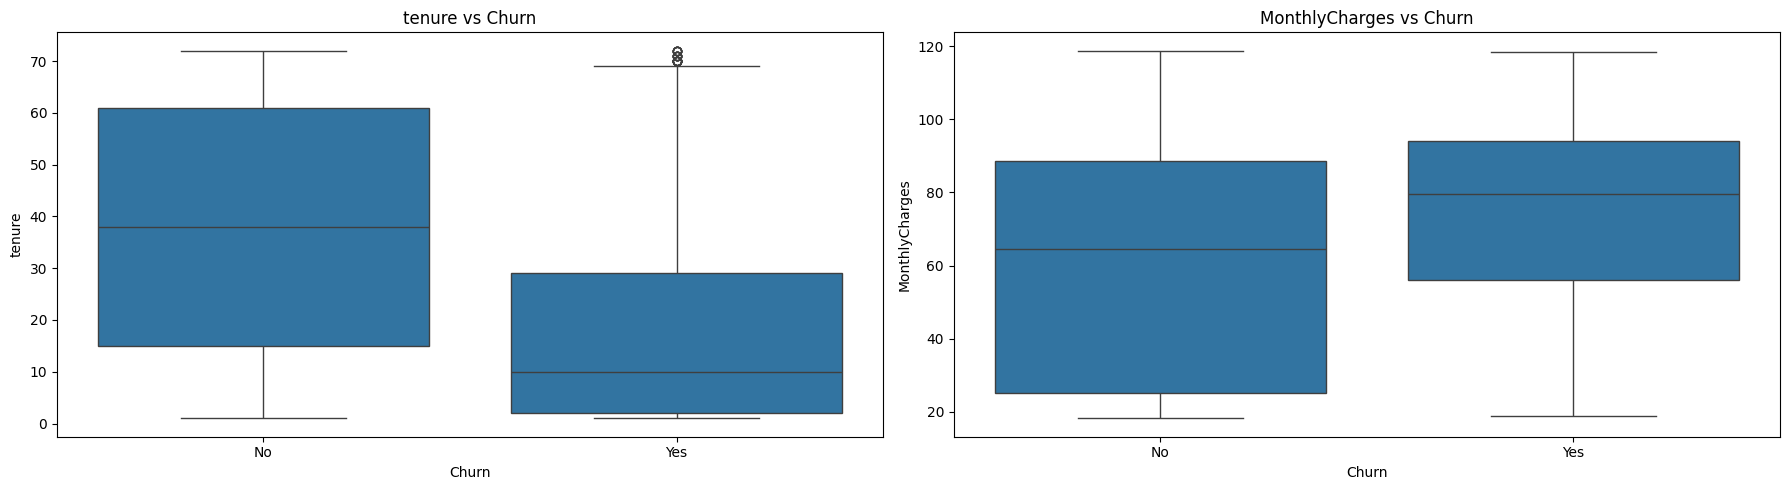

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
axes[0].set_title('tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title('MonthlyCharges vs Churn')

plt.tight_layout()
plt.show()

## Tenure vs Churn
Churned customers are heavily concentrated at low tenure (median very low)
Non-churn customers spread across higher tenure → long-term retention

### Insight:
Low tenure = strongest churn indicator (top feature, no debate)

## MonthlyCharges vs Churn
Churned customers have higher median monthly charges
Non-churn customers include more low-cost users

### Insight:
Higher pricing → increased churn probability (price sensitivity)

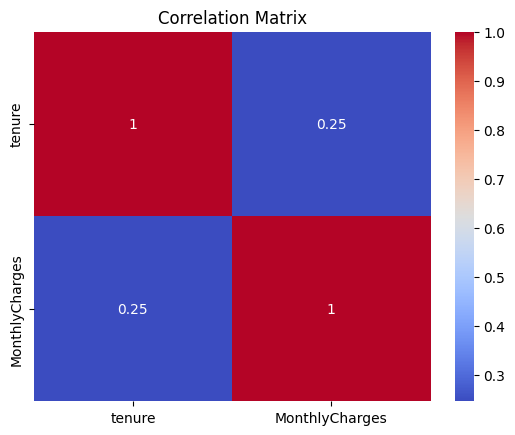

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['tenure', 'MonthlyCharges']  # exclude TotalCharges since dropped

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Observations
- Correlation = 0.25 → weak relationship between tenure and MonthlyCharges
- Both features provide independent information → no redundancy issue
- Confirms your earlier decision: dropping TotalCharges was correct
- No multicollinearity risk → safe for both linear and tree models

# ML Model Building

## Feature Selection and Splitting the data

In [150]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop('Churn', axis=1)

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Building Preprocessing Pipeline

In [152]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [153]:
print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['tenure', 'MonthlyCharges']


# Model Building

### Logistic Regression

In [154]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# build pipeline
log_reg = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# train
log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [155]:
y_pred = log_reg.predict(X_test)

In [156]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[915 118]
 [160 214]]


In [157]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [158]:
# imports
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [159]:
# scale_pos_weight for XGB
scale_pos_weight = (y_train == 0).sum() / (y_train== 1).sum()

# Models
models = {
    "log_reg": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "rf": RandomForestClassifier(class_weight='balanced', random_state=42),
    "gb": GradientBoostingClassifier(),
    "svc": SVC(class_weight='balanced', probability=True),
    "knn": KNeighborsClassifier(),
    "xgb": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
}

# train pipelines
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

In [160]:
comparison = []

for name, pipe in trained_models.items():

    y_pred = pipe.predict(X_test)

    comparison.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(comparison).sort_values(by="f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1
5,xgb,0.730633,0.495798,0.788770,0.608875
0,log_reg,0.727790,0.492437,0.783422,0.604747
3,svc,0.724947,0.489112,0.780749,0.601442
2,gb,0.794598,0.636656,0.529412,0.578102
4,knn,0.761905,0.549618,0.577540,0.563233
1,rf,0.782516,0.613333,0.491979,0.545994


In [161]:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual: No (0)", "Actual: Yes (1)"],
    columns=["Predicted: No (0)", "Predicted: Yes (1)"]
)

print(cm_df)

                 Predicted: No (0)  Predicted: Yes (1)
Actual: No (0)                 733                 300
Actual: Yes (1)                 79                 295


# Handling Imbalance Data

In [162]:
!pip install imbalanced-learn

In [163]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

In [164]:
models = {
    "log_reg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(random_state=42),
    "gb": GradientBoostingClassifier(),
    "svc": SVC(probability=True),
    "knn": KNeighborsClassifier(),
    "xgb": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
}

In [165]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_pipeline(pipe, X_train, X_test, y_train, y_test, name):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

In [166]:
results_smote = []

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    results_smote.append(
        evaluate_pipeline(pipe, X_train, X_test, y_train, y_test, f"{name}_smote")
    )

df_smote = pd.DataFrame(results_smote)

In [167]:
results_tomek = []

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote_tomek', SMOTETomek(random_state=42)),
        ('model', model)
    ])

    results_tomek.append(
        evaluate_pipeline(pipe, X_train, X_test, y_train, y_test, f"{name}_smotetomek")
    )

df_tomek = pd.DataFrame(results_tomek)

In [168]:
final_results = pd.concat([df_smote, df_tomek], ignore_index=True)
final_results.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
2,gb_smote,0.775409,0.560924,0.713904,0.628235
5,xgb_smote,0.782516,0.577626,0.676471,0.623153
11,xgb_smotetomek,0.782516,0.577626,0.676471,0.623153
3,svc_smote,0.756219,0.529865,0.735294,0.615901
8,gb_smotetomek,0.766880,0.548319,0.697861,0.614118
9,svc_smotetomek,0.754087,0.526923,0.732620,0.612975
6,log_reg_smotetomek,0.733475,0.499127,0.764706,0.604013
0,log_reg_smote,0.731343,0.496491,0.756684,0.599576
10,knn_smotetomek,0.702914,0.464052,0.759358,0.576065
7,rf_smotetomek,0.772566,0.571809,0.574866,0.573333


## Key Observations
- SMOTE improved tree models significantly (GB, XGB)
- Logistic didn’t improve much → already handling imbalance well
- RF still underperforms → not worth considering
- KNN is weak → ignore completely

# Final Comparison

## Without SMOTE

### Best: **XGBoost**

* Recall: **0.79 (highest)**
* F1: **0.61 (best)**
* Precision: 0.50


## With SMOTE

### Best: **GradientBoosting + SMOTE**

* Recall: 0.71
* F1: **0.63 (highest overall)**
* Precision: 0.56

---

# The Real Trade-off

## XGBoost (No SMOTE)

* Catches **more churners (79%)**
* More false positives
  → aggressive model


## GB + SMOTE

* More balanced predictions
* Misses more churners (~29% missed)
  → conservative model


## Decision :   

### Example 1 (Telecom retention team)

* Missing churner = lost revenue
  → choose **XGBoost**



### Example 2 (Cost-sensitive campaign)

* Calling wrong users is expensive
  → choose **GB + SMOTE**



# Final Answer


```python
XGBoost (without SMOTE)
```



# Why This Is the Right Call

* Your problem = **churn detection**
* Priority = **catch churners early**
* Not = “balanced metrics”


In [169]:
y_prob = xgb_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.4).astype(int)

In [170]:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_df_Threshold = pd.DataFrame(
    cm,
    index=["Actual: No (0)", "Actual: Yes (1)"],
    columns=["Predicted: No (0)", "Predicted: Yes (1)"]
)

print(cm_df_Threshold )

                 Predicted: No (0)  Predicted: Yes (1)
Actual: No (0)                 665                 368
Actual: Yes (1)                 61                 313


| Metric     | Before (0.5) | After (0.4) | Change   |
| ---------- | ------------ | ----------- | -------- |
| Recall (1) | 0.79         | **0.84**    | ↑ +0.05  |
| Precision  | 0.50         | **0.46**    | ↓ -0.04  |
| F1 Score   | 0.61         | **0.59**    | ↓ slight |
| Accuracy   | 0.73         | **0.70**    | ↓ -0.03  |


| Metric                | Threshold 0.5 | Threshold 0.4 | Change |
| --------------------- | ------------- | ------------- | ------ |
| **TN** (Correct No)   | 733           | 665           | ↓ -68  |
| **FP** (False Alarm)  | 300           | 368           | ↑ +68  |
| **FN** (Missed Churn) | 79            | 61            | ↓ -18  |
| **TP** (Caught Churn) | 295           | 313           | ↑ +18  |


## Final Observation (Model Selection Justification)

* **XGBoost is selected because it delivers the highest churn detection capability (Recall ≈ 0.79 → 0.84 after threshold tuning)**, which is the primary objective in a churn problem.

* It also achieves the **best overall balance (F1 ≈ 0.61 baseline)** compared to other models, slightly outperforming Logistic Regression and SVC.

* After threshold tuning (0.5 → 0.4), the model **captures 18 additional churners (TP: 295 → 313)** and reduces missed churners (FN: 79 → 61), directly improving business impact.

* Although precision drops (0.50 → 0.46) and false positives increase, this trade-off is acceptable because **retaining a potential churner is more valuable than avoiding a false alert**.



## Final Conclusion

> XGBoost is chosen because it maximizes churn detection (high recall) while maintaining a reasonable balance with precision and F1-score, making it the most effective model for proactive customer retention.


# Model Serialization

In [171]:
import joblib

final_model = {
    "model": trained_models["xgb"],
    "threshold": 0.4
}

joblib.dump(final_model, "churn_model.pkl")

['churn_model.pkl']

In [172]:
final_model = {
    "model": trained_models["xgb"],
    "threshold": 0.4,
    "features": X_train.columns.tolist()
}